# 🎙️ Wav2Vec2 Emotion Recognition
**Dataset:** CREMA-D + RAVDESS | **Epochs:** 25 | **Device:** CUDA

### ✅ All fixes applied:
- torch 2.6+ compatible
- safetensors issue fixed
- pytorch_model.bin download
- Windows num_workers=0
- Pre-split dataset support

In [1]:
# ═══════════════════════════════════════════════════════════
# CELL 1 — INSTALL
# ═══════════════════════════════════════════════════════════
import sys
!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!{sys.executable} -m pip install transformers accelerate librosa scikit-learn tqdm matplotlib seaborn huggingface_hub
print('\n✅ Done')

Looking in indexes: https://download.pytorch.org/whl/cu118

✅ Done


In [2]:
# ═══════════════════════════════════════════════════════════
# CELL 2 — VERIFY CUDA
# ═══════════════════════════════════════════════════════════
import torch
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'\n✅ Device: {DEVICE}')

PyTorch : 2.7.1+cu118
CUDA    : True
GPU     : NVIDIA GeForce RTX 4050 Laptop GPU

✅ Device: cuda


In [3]:
# ═══════════════════════════════════════════════════════════
# CELL 3 — IMPORTS
# ═══════════════════════════════════════════════════════════
import os
import random
import numpy as np
import librosa
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import Wav2Vec2Processor, Wav2Vec2Model
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
print('✅ Imports done')

✅ Imports done


In [4]:
# ═══════════════════════════════════════════════════════════
# CELL 4 — CONFIG
# ═══════════════════════════════════════════════════════════
CONFIG = {
    'BASE_DIR'       : 'dataset_voice/split_combined',
    'MODEL_PATH'     : './wav2vec2-base',
    'CHECKPOINT_DIR' : 'checkpoints',
    'LOG_DIR'        : 'logs',
    'SAMPLE_RATE'    : 16000,
    'MAX_DURATION'   : 3.0,
    'EPOCHS'         : 25,
    'BATCH_SIZE'     : 16,
    'LEARNING_RATE'  : 1e-4,
    'WEIGHT_DECAY'   : 1e-4,
    'DROPOUT'        : 0.3,
    'PATIENCE'       : 6,
    'NUM_WORKERS'    : 0,
}
os.makedirs(CONFIG['CHECKPOINT_DIR'], exist_ok=True)
os.makedirs(CONFIG['LOG_DIR'], exist_ok=True)
print('✅ Config ready')

✅ Config ready


In [5]:
# ═══════════════════════════════════════════════════════════
# CELL 5 — DOWNLOAD WAV2VEC2 MODEL
# ═══════════════════════════════════════════════════════════
from huggingface_hub import hf_hub_download, snapshot_download
import shutil

MODEL_PATH = CONFIG['MODEL_PATH']

# Fresh download
if not os.path.exists(os.path.join(MODEL_PATH, 'pytorch_model.bin')):
    if os.path.exists(MODEL_PATH):
        shutil.rmtree(MODEL_PATH)
    os.makedirs(MODEL_PATH, exist_ok=True)

    print('Downloading config files...')
    snapshot_download(
        repo_id='facebook/wav2vec2-base',
        local_dir=MODEL_PATH,
        local_dir_use_symlinks=False,
        ignore_patterns=['*.msgpack', '*.h5', 'flax_model*', 'tf_model*', 'rust_model*', '*.safetensors']
    )

    print('Downloading model weights (pytorch_model.bin ~360MB)...')
    hf_hub_download(
        repo_id='facebook/wav2vec2-base',
        filename='pytorch_model.bin',
        local_dir=MODEL_PATH,
        local_dir_use_symlinks=False
    )
    print('✅ Download complete!')
else:
    print('✅ Model already downloaded')

print('\n📁 Files:')
for f in os.listdir(MODEL_PATH):
    size = os.path.getsize(os.path.join(MODEL_PATH, f))
    print(f'   {f}  ({size/1024/1024:.1f} MB)')

✅ Model already downloaded

📁 Files:
   .cache  (0.0 MB)
   .gitattributes  (0.0 MB)
   config.json  (0.0 MB)
   preprocessor_config.json  (0.0 MB)
   pytorch_model.bin  (362.7 MB)
   README.md  (0.0 MB)
   special_tokens_map.json  (0.0 MB)
   tokenizer_config.json  (0.0 MB)
   vocab.json  (0.0 MB)


In [6]:
# ═══════════════════════════════════════════════════════════
# CELL 6 — DATASET CLASS
# ═══════════════════════════════════════════════════════════
class EmotionDataset(Dataset):
    def __init__(self, file_paths, labels, processor, config, augment=False):
        self.file_paths = file_paths
        self.labels     = labels
        self.processor  = processor
        self.config     = config
        self.augment    = augment
        self.max_len    = int(config['SAMPLE_RATE'] * config['MAX_DURATION'])

    def __len__(self):
        return len(self.file_paths)

    def _augment(self, audio):
        if random.random() < 0.5:
            audio = np.roll(audio, random.randint(-1600, 1600))
        if random.random() < 0.4:
            audio = audio + np.random.normal(0, 0.004, audio.shape)
        if random.random() < 0.3:
            audio = librosa.effects.pitch_shift(
                audio, sr=self.config['SAMPLE_RATE'],
                n_steps=random.uniform(-2, 2)
            )
        return audio

    def __getitem__(self, idx):
        audio, _ = librosa.load(
            self.file_paths[idx],
            sr=self.config['SAMPLE_RATE'], mono=True
        )
        if len(audio) < self.max_len:
            audio = np.pad(audio, (0, self.max_len - len(audio)))
        else:
            audio = audio[:self.max_len]
        if self.augment:
            audio = self._augment(audio)
        inputs = self.processor(
            audio, sampling_rate=self.config['SAMPLE_RATE'],
            return_tensors='pt', padding=True
        )
        return inputs.input_values.squeeze(0), torch.tensor(self.labels[idx], dtype=torch.long)


def load_split(base_dir, split_name):
    file_paths, raw_labels = [], []
    supported = ('.wav', '.mp3', '.flac', '.ogg')
    split_dir = os.path.join(base_dir, split_name)
    for emotion in sorted(os.listdir(split_dir)):
        emotion_dir = os.path.join(split_dir, emotion)
        if not os.path.isdir(emotion_dir):
            continue
        for fname in os.listdir(emotion_dir):
            if fname.lower().endswith(supported):
                file_paths.append(os.path.join(emotion_dir, fname))
                raw_labels.append(emotion)
    return file_paths, raw_labels

print('✅ Dataset class ready')

✅ Dataset class ready


In [7]:
# ═══════════════════════════════════════════════════════════
# CELL 7 — WAV2VEC2 MODEL (FROZEN — FEATURE EXTRACTION ONLY)
# ═══════════════════════════════════════════════════════════
class Wav2Vec2Classifier(nn.Module):
    def __init__(self, num_classes, dropout=0.5):
        super().__init__()
        self.wav2vec2 = Wav2Vec2Model.from_pretrained(
            CONFIG['MODEL_PATH'],
            use_safetensors=False
        )
        # Poora Wav2Vec2 freeze — sirf classifier train hoga
        for param in self.wav2vec2.parameters():
            param.requires_grad = False

        self.classifier = nn.Sequential(
            nn.Linear(768, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(64, num_classes)
        )

    def forward(self, input_values):
        with torch.no_grad():
            outputs = self.wav2vec2(input_values)
        hidden = outputs.last_hidden_state.mean(dim=1)
        return self.classifier(hidden)

print('✅ Model defined — Wav2Vec2 fully frozen')

✅ Model defined — Wav2Vec2 fully frozen


In [8]:
# ═══════════════════════════════════════════════════════════
# CELL 8 — TRAINING FUNCTIONS
# ═══════════════════════════════════════════════════════════
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for inputs, labels in tqdm(loader, desc='  Train', leave=False):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss    = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * inputs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total * 100


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for inputs, labels in tqdm(loader, desc='  Val  ', leave=False):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss    = criterion(outputs, labels)
        total_loss += loss.item() * inputs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total * 100


class EarlyStopping:
    def __init__(self, patience=6):
        self.patience  = patience
        self.counter   = 0
        self.best_loss = None
        self.stop      = False
    def __call__(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss - 0.001:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

print('✅ Training functions ready')

✅ Training functions ready


In [9]:
# ═══════════════════════════════════════════════════════════
# CELL 9 — LOAD DATA + TRAIN (25 EPOCHS)
# ═══════════════════════════════════════════════════════════

# 1. Processor
print('Loading processor...')
processor = Wav2Vec2Processor.from_pretrained(CONFIG['MODEL_PATH'])
print('✅ Processor loaded')

# 2. Data
train_paths, train_raw = load_split(CONFIG['BASE_DIR'], 'train')
val_paths,   val_raw   = load_split(CONFIG['BASE_DIR'], 'val')
test_paths,  test_raw  = load_split(CONFIG['BASE_DIR'], 'test')

label_encoder = LabelEncoder()
label_encoder.fit(train_raw)
train_labels  = label_encoder.transform(train_raw).tolist()
val_labels    = label_encoder.transform(val_raw).tolist()
test_labels   = label_encoder.transform(test_raw).tolist()
num_classes   = len(label_encoder.classes_)

print(f'✅ Classes ({num_classes}): {list(label_encoder.classes_)}')
print(f'   Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}')

# 3. Updated CONFIG for frozen model
CONFIG['LEARNING_RATE'] = 1e-3   # higher LR — sirf classifier train ho raha
CONFIG['BATCH_SIZE']    = 32      # larger batch
CONFIG['DROPOUT']       = 0.5
CONFIG['PATIENCE']      = 8

# 4. Datasets
train_ds = EmotionDataset(train_paths, train_labels, processor, CONFIG, augment=True)
val_ds   = EmotionDataset(val_paths,   val_labels,   processor, CONFIG, augment=False)
test_ds  = EmotionDataset(test_paths,  test_labels,  processor, CONFIG, augment=False)

train_loader = DataLoader(train_ds, batch_size=CONFIG['BATCH_SIZE'], shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG['BATCH_SIZE'], shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG['BATCH_SIZE'], shuffle=False, num_workers=0)

# 5. Model
model     = Wav2Vec2Classifier(num_classes=num_classes, dropout=CONFIG['DROPOUT']).to(DEVICE)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG['LEARNING_RATE'],
    weight_decay=CONFIG['WEIGHT_DECAY']
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG['EPOCHS'], eta_min=1e-6
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'✅ Model on {DEVICE}')
print(f'   Total params    : {total:,}')
print(f'   Trainable params: {trainable:,}  (frozen: {total-trainable:,})')

# 6. Training Loop
early_stopping = EarlyStopping(patience=CONFIG['PATIENCE'])
best_val_acc   = 0.0
history        = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print('\n' + '='*65)
print(f'  Wav2Vec2 Frozen  |  25 Epochs  |  {DEVICE}')
print('='*65)

for epoch in range(1, CONFIG['EPOCHS'] + 1):
    lr = optimizer.param_groups[0]['lr']
    print(f'\nEpoch [{epoch:02d}/{CONFIG["EPOCHS"]}]  LR: {lr:.6f}')

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss,   val_acc   = validate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'  Train  →  Loss: {train_loss:.4f}  |  Acc: {train_acc:.2f}%')
    print(f'  Val    →  Loss: {val_loss:.4f}  |  Acc: {val_acc:.2f}%')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        # Save as super_fast_model
        torch.save({
            'epoch'               : epoch,
            'model_state_dict'    : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc'             : val_acc,
            'label_encoder'       : label_encoder,
            'config'              : CONFIG,
        }, os.path.join(CONFIG['CHECKPOINT_DIR'], 'super_fast_model.pth'))
        print(f'  💾 Saved super_fast_model  (val_acc: {best_val_acc:.2f}%)')

    early_stopping(val_loss)
    if early_stopping.stop:
        print(f'\n⏹  Early stopping at epoch {epoch}')
        break

print(f'\n✅ Done! Best Val Accuracy: {best_val_acc:.2f}%')

Loading processor...
✅ Processor loaded
✅ Classes (5): [np.str_('calm'), np.str_('extreme'), np.str_('high'), np.str_('low'), np.str_('moderate')]
   Train: 6188 | Val: 1350 | Test: 1344


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: ./wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model on cuda
   Total params    : 94,585,989
   Trainable params: 214,277  (frozen: 94,371,712)

  Wav2Vec2 Frozen  |  25 Epochs  |  cuda

Epoch [01/25]  LR: 0.001000


  Train  →  Loss: 1.4001  |  Acc: 43.50%
  Val    →  Loss: 1.3945  |  Acc: 44.00%
  💾 Saved super_fast_model  (val_acc: 44.00%)

Epoch [02/25]  LR: 0.000996


...

  Train  →  Loss: 1.1964  |  Acc: 56.97%
  Val    →  Loss: 1.2045  |  Acc: 54.59%

Epoch [17/25]  LR: 0.000288


  Train  →  Loss: 1.1832  |  Acc: 57.84%
  Val    →  Loss: 1.2089  |  Acc: 54.22%

Epoch [18/25]  LR: 0.000233


  Train  →  Loss: 1.1704  |  Acc: 58.27%
  Val    →  Loss: 1.2070  |  Acc: 55.56%

Epoch [19/25]  LR: 0.000182


  Train  →  Loss: 1.1756  |  Acc: 58.05%
  Val    →  Loss: 1.2013  |  Acc: 55.33%

Epoch [20/25]  LR: 0.000136


  Train  →  Loss: 1.1764  |  Acc: 58.02%
  Val    →  Loss: 1.1986  |  Acc: 56.07%

⏹  Early stopping at epoch 20

✅ Done! Best Val Accuracy: 56.67%


In [15]:
import os

path = os.path.join(CONFIG['CHECKPOINT_DIR'], 'super_fast_model.pth')
size = os.path.getsize(path)
print(f"✅ File exists: {path}")
print(f"   Size: {size/1024/1024:.1f} MB")

✅ File exists: checkpoints\super_fast_model.pth
   Size: 362.6 MB


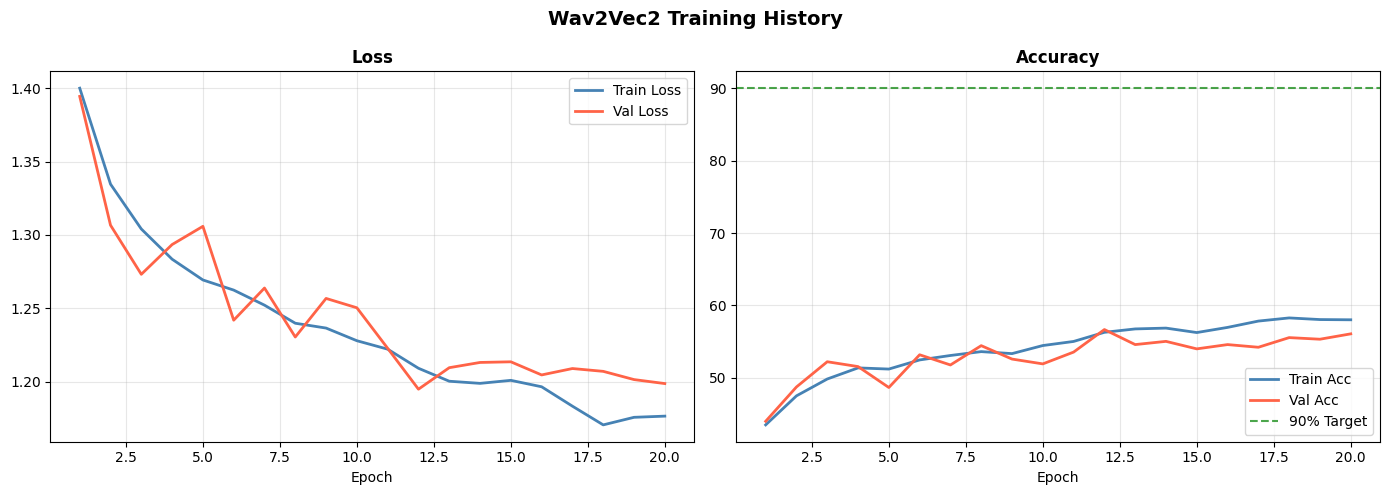

✅ Saved to logs/training_curves.png


In [10]:
# ═══════════════════════════════════════════════════════════
# CELL 10 — TRAINING CURVES
# ═══════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_ran = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_ran, history['train_loss'], label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(epochs_ran, history['val_loss'],   label='Val Loss',   color='tomato',    linewidth=2)
axes[0].set_title('Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, history['train_acc'], label='Train Acc', color='steelblue', linewidth=2)
axes[1].plot(epochs_ran, history['val_acc'],   label='Val Acc',   color='tomato',    linewidth=2)
axes[1].axhline(y=90, color='green', linestyle='--', alpha=0.7, label='90% Target')
axes[1].set_title('Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Wav2Vec2 Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['LOG_DIR'], 'training_curves.png'), dpi=150)
plt.show()
print('✅ Saved to logs/training_curves.png')

✅ Best model loaded — Epoch 12 | Val Acc: 56.67%


Testing: 100%|█████████████████████████████████████████████████████████████████████████| 42/42 [00:33<00:00,  1.24it/s]



  TEST SET RESULTS
              precision    recall  f1-score   support

        calm       0.59      0.69      0.64       216
     extreme       0.55      0.34      0.42       216
        high       0.66      0.65      0.66       216
         low       0.42      0.56      0.48       264
    moderate       0.63      0.58      0.60       432

    accuracy                           0.57      1344
   macro avg       0.57      0.56      0.56      1344
weighted avg       0.58      0.57      0.56      1344



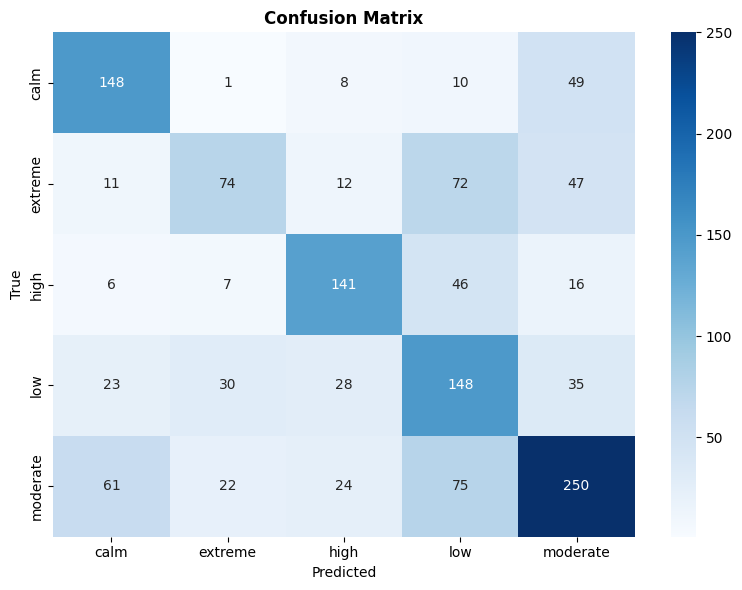

✅ Evaluation done


In [16]:
# ═══════════════════════════════════════════════════════════
# CELL 11 — TEST SET EVALUATION
# ═══════════════════════════════════════════════════════════
ckpt = torch.load(
    os.path.join(CONFIG['CHECKPOINT_DIR'], 'super_fast_model.pth'),
    map_location=DEVICE,
    weights_only=False
)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f"✅ Best model loaded — Epoch {ckpt['epoch']} | Val Acc: {ckpt['val_acc']:.2f}%")

all_preds, all_labels_list = [], []
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc='Testing'):
        outputs = model(inputs.to(DEVICE))
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels_list.extend(labels.numpy())

print('\n' + '='*55)
print('  TEST SET RESULTS')
print('='*55)
print(classification_report(all_labels_list, all_preds, target_names=label_encoder.classes_))

cm = confusion_matrix(all_labels_list, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix', fontweight='bold')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['LOG_DIR'], 'confusion_matrix.png'), dpi=150)
plt.show()
print('✅ Evaluation done')

In [12]:
# ═══════════════════════════════════════════════════════════
# CELL 12 — INFERENCE
# ═══════════════════════════════════════════════════════════
def predict(audio_path):
    model.eval()
    max_len = int(CONFIG['SAMPLE_RATE'] * CONFIG['MAX_DURATION'])

    audio, _ = librosa.load(audio_path, sr=CONFIG['SAMPLE_RATE'], mono=True)
    if len(audio) < max_len:
        audio = np.pad(audio, (0, max_len - len(audio)))
    else:
        audio = audio[:max_len]

    inputs = processor(
        audio, sampling_rate=CONFIG['SAMPLE_RATE'],
        return_tensors='pt', padding=True
    )
    with torch.no_grad():
        output = model(inputs.input_values.to(DEVICE))
        probs  = torch.softmax(output, dim=1)[0]
        pred   = output.argmax(1).item()

    predicted_class = label_encoder.classes_[pred]
    confidence      = probs[pred].item() * 100

    print(f'\n🎙️  File       : {os.path.basename(audio_path)}')
    print(f'   Prediction : {predicted_class.upper()}')
    print(f'   Confidence : {confidence:.1f}%')
    print('\n   Probabilities:')
    for cls, prob in zip(label_encoder.classes_, probs):
        bar = '█' * int(prob.item() * 40)
        print(f'   {cls:12s} {prob.item()*100:5.1f}%  {bar}')
    return predicted_class, confidence


print('✅ Inference ready!')
print("   Usage: predict('path/to/audio.wav')")

✅ Inference ready!
   Usage: predict('path/to/audio.wav')
